# ₿ Bitcoin Market Trend Prediction Using Machine Learning

## Week 6 Capstone Project | Machine Learning Internship

### Project Overview

This project develops an end-to-end Machine Learning system to predict the short-term direction of Bitcoin's market price.

Using historical Bitcoin market data, the project performs data cleaning, exploratory data analysis, feature engineering, model training, evaluation, hyperparameter tuning, and deployment.

The objective is to classify whether Bitcoin's closing price will move UP or DOWN on the following day.

---

## Machine Learning Workflow

1. Data Collection
2. Data Understanding
3. Data Cleaning
4. Exploratory Data Analysis
5. Feature Engineering
6. Target Variable Creation
7. Model Training
8. Model Evaluation
9. Hyperparameter Tuning
10. Final Model Selection
11. Model Saving
12. Deployment

---

> **Disclaimer:** This project is created for educational and research purposes only. Cryptocurrency markets are highly volatile, and the predictions generated by this model should not be considered financial advice.

# Import Required Libraries

In [ ]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# XGBoost
from xgboost import XGBClassifier

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

# Model Saving
import joblib

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

# Visualization Settings
sns.set_theme(style="whitegrid")

print("All libraries imported successfully!")

All libraries imported successfully!


# 1. Data Collection

The dataset used in this project contains historical daily Bitcoin (BTC-USD) market data.

The dataset includes the following market variables:

- Date
- Open
- High
- Low
- Close
- Adjusted Close
- Volume

The data will be used to engineer technical indicators and build a machine learning classification model for predicting the next day's market direction.

# Load the Dataset

In [ ]:
df = pd.read_csv("BTC-USD_2014_2023.csv")

print("Dataset loaded successfully!")
print("Dataset Shape:", df.shape)

df.head()

Dataset loaded successfully!
Dataset Shape: (3288, 7)


,Date,Open,High,Low,Close,Adj Close,Volume
0,2014-09-17,465.864014,468.174011,452.421997,457.334015,457.334015,21056800
1,2014-09-18,456.859985,456.859985,413.104004,424.440002,424.440002,34483200
2,2014-09-19,424.102997,427.834991,384.532013,394.795990,394.795990,37919700
3,2014-09-20,394.673004,423.295990,389.882996,408.903992,408.903992,36863600
4,2014-09-21,408.084991,412.425995,393.181000,398.821014,398.821014,26580100


# 2. Data Understanding

Before performing any preprocessing, it is important to understand the dataset structure, data types, and available features.

In [ ]:
# Display basic information about the dataset

print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nFirst Five Rows:")
display(df.head())

Dataset Shape:
(3288, 7)

Column Names:
['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']

Data Types:
Date          object
Open         float64
High         float64
Low          float64
Close        float64
Adj Close    float64
Volume         int64
dtype: object

First Five Rows:


,Date,Open,High,Low,Close,Adj Close,Volume
0,2014-09-17,465.864014,468.174011,452.421997,457.334015,457.334015,21056800
1,2014-09-18,456.859985,456.859985,413.104004,424.440002,424.440002,34483200
2,2014-09-19,424.102997,427.834991,384.532013,394.795990,394.795990,37919700
3,2014-09-20,394.673004,423.295990,389.882996,408.903992,408.903992,36863600
4,2014-09-21,408.084991,412.425995,393.181000,398.821014,398.821014,26580100


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3288 entries, 0 to 3287
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       3288 non-null   object 
 1   Open       3288 non-null   float64
 2   High       3288 non-null   float64
 3   Low        3288 non-null   float64
 4   Close      3288 non-null   float64
 5   Adj Close  3288 non-null   float64
 6   Volume     3288 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 179.9+ KB


In [ ]:
df.describe()

,Open,High,Low,Close,Adj Close,Volume
count,3288.000000,3288.000000,3288.000000,3288.000000,3288.000000,3.288000e+03
mean,13921.103443,14252.603304,13557.404109,13927.687080,13927.687080,1.649503e+10
std,15983.770988,16376.213305,15535.188750,15980.429189,15980.429189,1.933155e+10
min,176.897003,211.731003,171.509995,178.102997,178.102997,5.914570e+06
25%,780.502731,791.496735,777.921982,784.050491,784.050491,1.361712e+08
50%,7953.345947,8163.982178,7744.868409,7958.903809,7958.903809,1.067175e+10
75%,21503.984375,21803.264649,20957.500489,21529.596192,21529.596192,2.720649e+10
max,67549.734375,68789.625000,66382.062500,67566.828125,67566.828125,3.509679e+11


## Missing Values Analysis

Checking for missing values is an important step before performing feature engineering and model training.

In [ ]:
missing_values = df.isnull().sum()

print("Missing Values Per Column:")
print(missing_values)

Missing Values Per Column:
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64


In [ ]:
duplicate_count = df.duplicated().sum()

print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 0


# Check Date Range

In [ ]:
# Convert Date column to datetime format

df["Date"] = pd.to_datetime(df["Date"])

print("Start Date:", df["Date"].min())
print("End Date:", df["Date"].max())

Start Date: 2014-09-17 00:00:00
End Date: 2023-09-17 00:00:00


# Sort Data Chronologically

In [ ]:
df = df.sort_values(by="Date").reset_index(drop=True)

print("Data sorted chronologically!")
display(df.head())

Data sorted chronologically!


,Date,Open,High,Low,Close,Adj Close,Volume
0,2014-09-17,465.864014,468.174011,452.421997,457.334015,457.334015,21056800
1,2014-09-18,456.859985,456.859985,413.104004,424.440002,424.440002,34483200
2,2014-09-19,424.102997,427.834991,384.532013,394.795990,394.795990,37919700
3,2014-09-20,394.673004,423.295990,389.882996,408.903992,408.903992,36863600
4,2014-09-21,408.084991,412.425995,393.181000,398.821014,398.821014,26580100


# 3. Data Cleaning

The dataset was checked for missing values and duplicate records.

- No missing values were found.
- No duplicate records were found.
- The `Date` column was converted to datetime format.
- The dataset was sorted chronologically.

Since the dataset is already clean, no additional imputation or duplicate removal was required.

In [ ]:
# Check for zero or negative values in important numerical columns

numerical_columns = ["Open", "High", "Low", "Close", "Volume"]

for column in numerical_columns:
    invalid_count = (df[column] <= 0).sum()
    print(f"{column}: {invalid_count} zero or negative values")

Open: 0 zero or negative values
High: 0 zero or negative values
Low: 0 zero or negative values
Close: 0 zero or negative values
Volume: 0 zero or negative values


# 4. Exploratory Data Analysis (EDA)

Exploratory Data Analysis is performed to understand Bitcoin's historical price behavior, trading volume, price distribution, and market trends.

The following visualizations will help identify patterns and characteristics in the dataset before feature engineering and machine learning.

# Bitcoin Closing Price Over Time

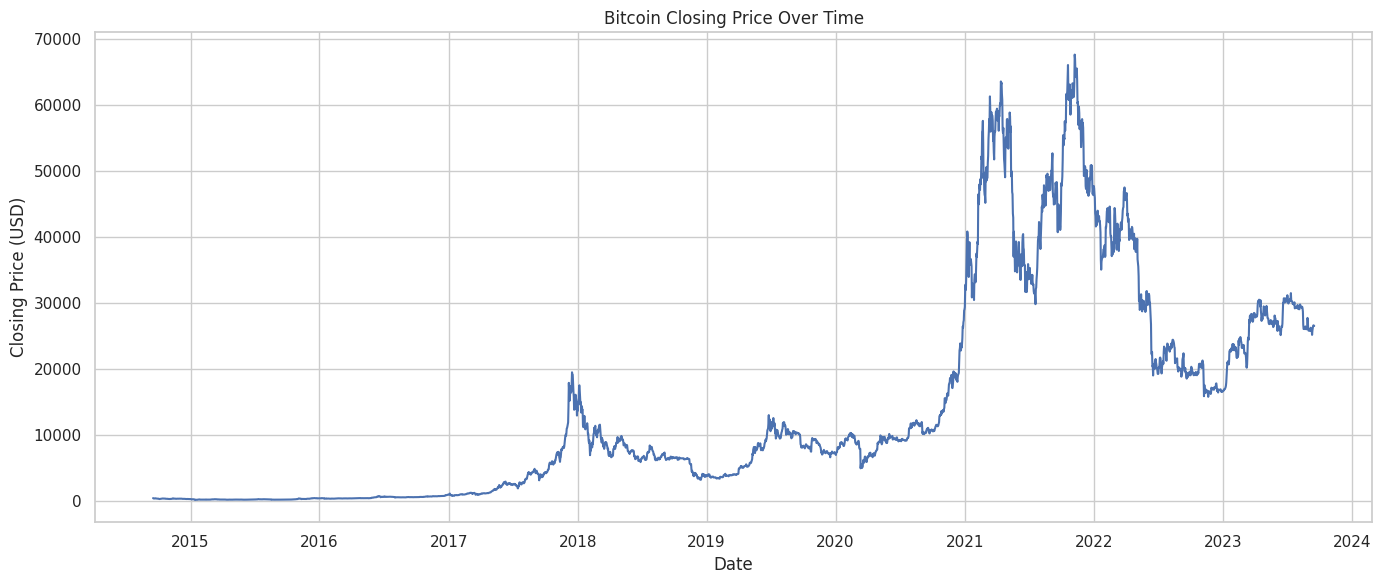

In [ ]:
plt.figure(figsize=(14, 6))

plt.plot(df["Date"], df["Close"])

plt.title("Bitcoin Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Closing Price (USD)")

plt.tight_layout()
plt.show()

# Trading Volume Over Time

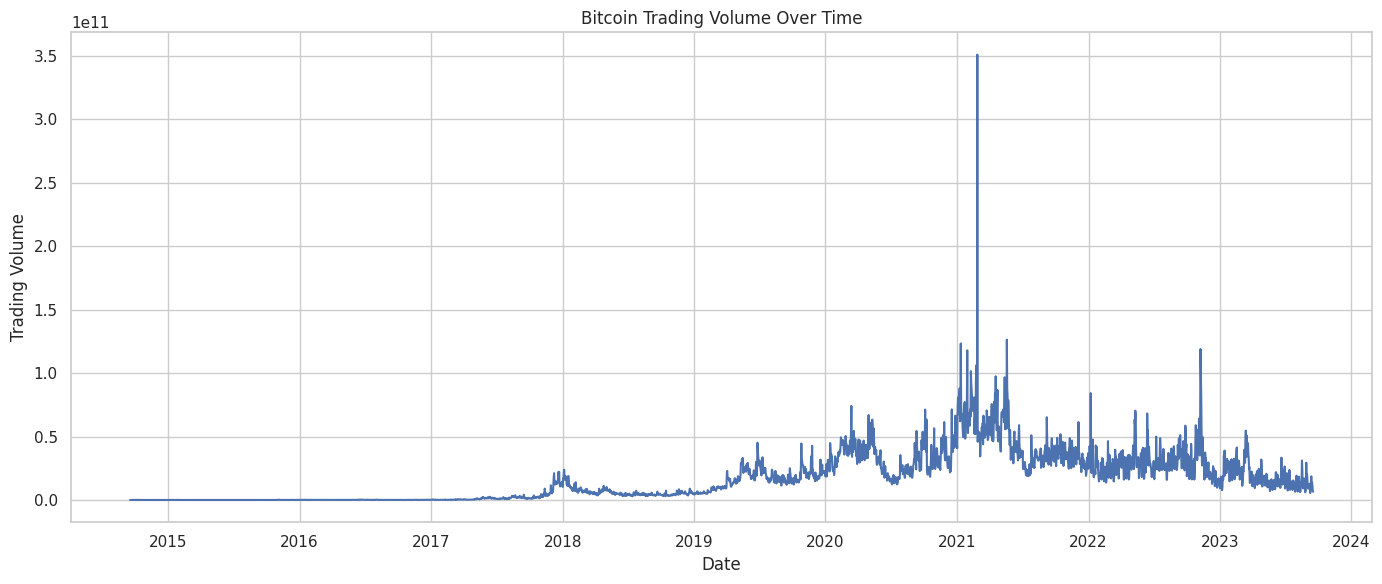

In [ ]:
plt.figure(figsize=(14, 6))

plt.plot(df["Date"], df["Volume"])

plt.title("Bitcoin Trading Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Trading Volume")

plt.tight_layout()
plt.show()

# Closing Price Distribution

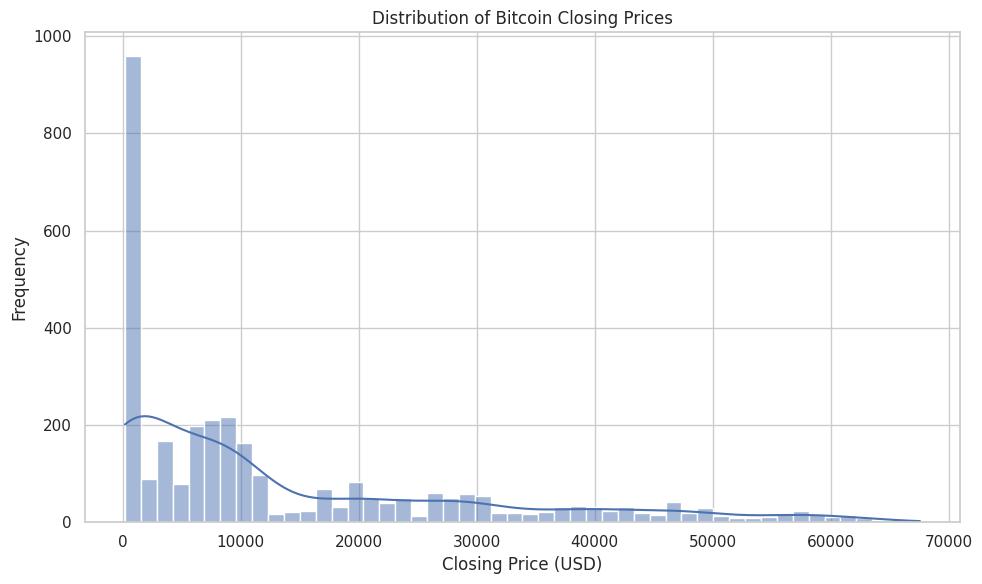

In [ ]:
plt.figure(figsize=(10, 6))

sns.histplot(df["Close"], bins=50, kde=True)

plt.title("Distribution of Bitcoin Closing Prices")
plt.xlabel("Closing Price (USD)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

## Daily Returns Analysis

Daily percentage returns measure the relative change in Bitcoin's closing price from one day to the next.

In [ ]:
# Calculate daily percentage return

df["Daily_Return"] = df["Close"].pct_change() * 100

df[["Date", "Close", "Daily_Return"]].head()

,Date,Close,Daily_Return
0,2014-09-17,457.334015,NaN
1,2014-09-18,424.440002,-7.192558
2,2014-09-19,394.795990,-6.984264
3,2014-09-20,408.903992,3.573492
4,2014-09-21,398.821014,-2.465855


# Visualize Daily Returns

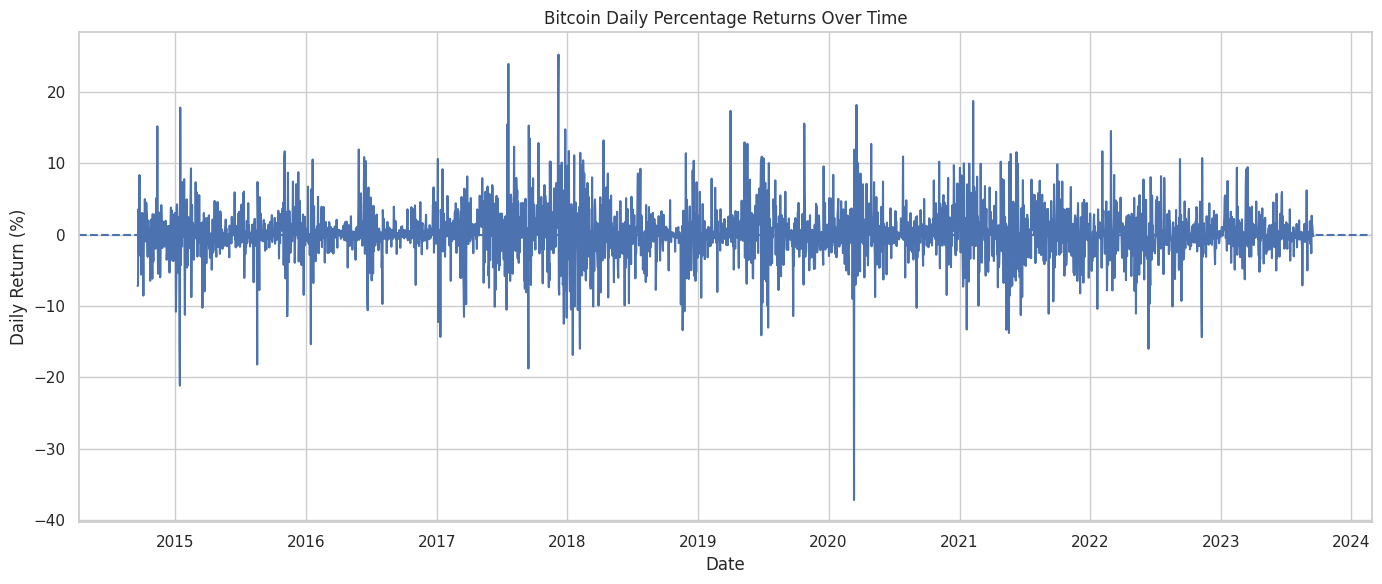

In [ ]:
plt.figure(figsize=(14, 6))

plt.plot(df["Date"], df["Daily_Return"])

plt.title("Bitcoin Daily Percentage Returns Over Time")
plt.xlabel("Date")
plt.ylabel("Daily Return (%)")

plt.axhline(y=0, linestyle="--")

plt.tight_layout()
plt.show()

# Daily Returns Distribution

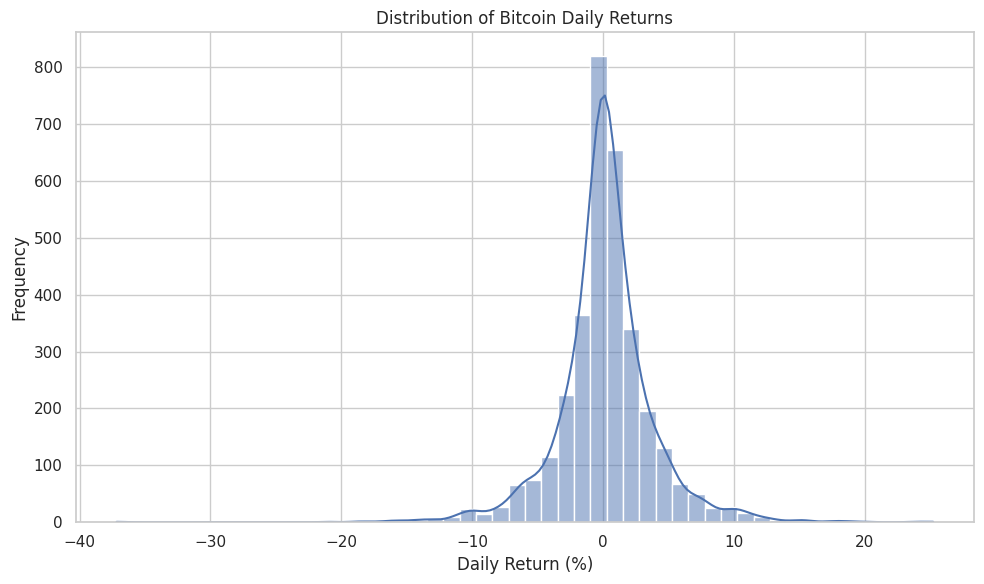

In [ ]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df["Daily_Return"].dropna(),
    bins=50,
    kde=True
)

plt.title("Distribution of Bitcoin Daily Returns")
plt.xlabel("Daily Return (%)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

# OHLC Price Comparison

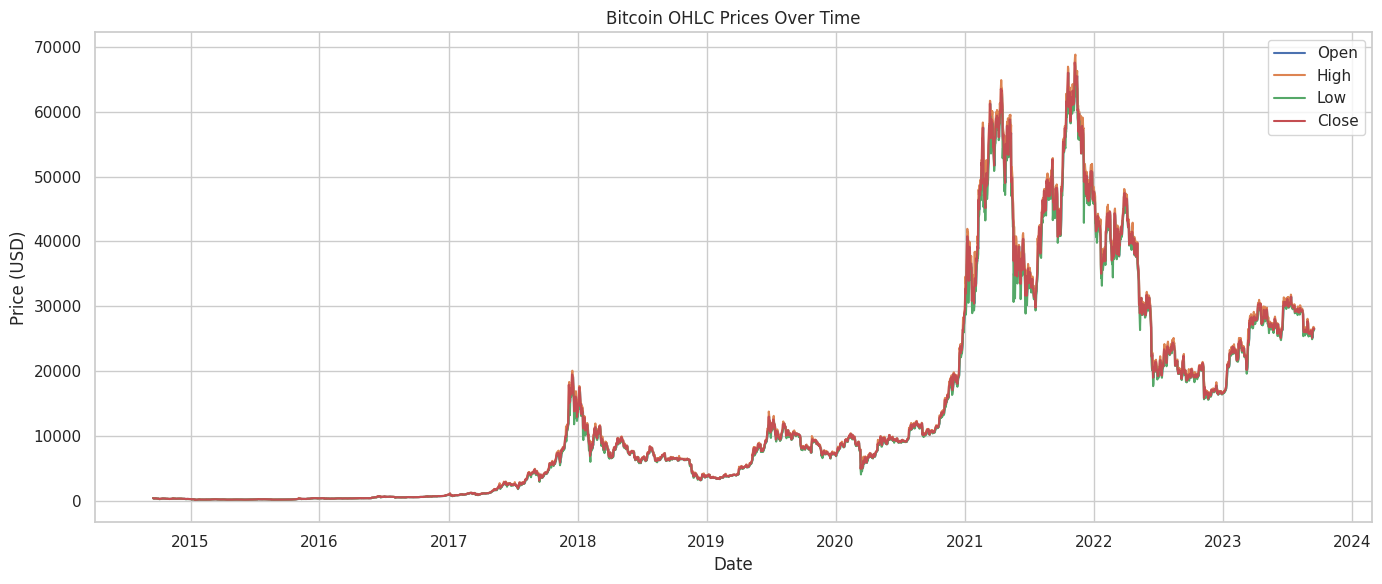

In [ ]:
plt.figure(figsize=(14, 6))

plt.plot(df["Date"], df["Open"], label="Open")
plt.plot(df["Date"], df["High"], label="High")
plt.plot(df["Date"], df["Low"], label="Low")
plt.plot(df["Date"], df["Close"], label="Close")

plt.title("Bitcoin OHLC Prices Over Time")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()

plt.tight_layout()
plt.show()

## Correlation Analysis

A correlation heatmap is used to examine relationships between the numerical market variables.

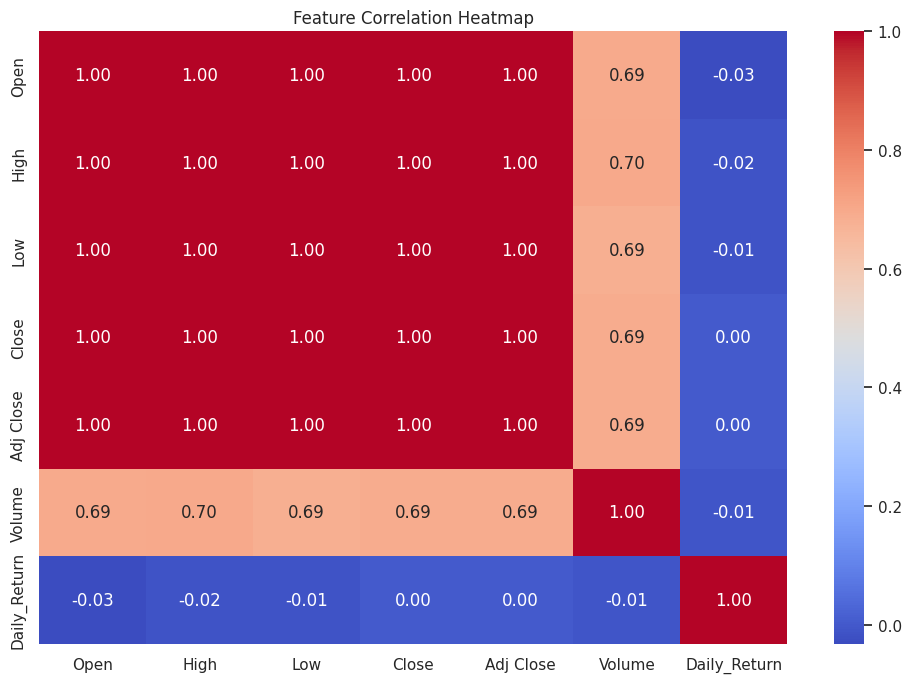

In [ ]:
# Select numerical columns for correlation analysis

correlation_columns = [
    "Open",
    "High",
    "Low",
    "Close",
    "Adj Close",
    "Volume",
    "Daily_Return"
]

correlation_matrix = df[correlation_columns].corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Feature Correlation Heatmap")

plt.tight_layout()
plt.show()

## Key EDA Observations

- Bitcoin's closing price shows substantial long-term growth along with periods of significant volatility.
- Trading volume fluctuates considerably, reflecting changes in market activity over time.
- Daily returns are centered around zero but contain extreme positive and negative movements, highlighting the volatile nature of cryptocurrency markets.
- The Open, High, Low, and Close prices are strongly correlated because they represent related price information from the same trading day.
- The observed volatility suggests that technical indicators and engineered features may provide useful information for predicting short-term market direction.

# 5. Feature Engineering

Feature engineering is the process of creating meaningful input variables from raw data to improve machine learning model performance.

For this project, several technical indicators and market-based features are created from historical Bitcoin price and volume data.

The engineered features include:

- Moving Averages (SMA)
- Exponential Moving Averages (EMA)
- Relative Strength Index (RSI)
- MACD
- Market Volatility
- Volume Change
- Daily Price Range

# Create Simple Moving Averages (SMA)

In [ ]:
# Simple Moving Averages

df["SMA_7"] = df["Close"].rolling(window=7).mean()

df["SMA_14"] = df["Close"].rolling(window=14).mean()

df["SMA_30"] = df["Close"].rolling(window=30).mean()

df[["Date", "Close", "SMA_7", "SMA_14", "SMA_30"]].head(35)

,Date,Close,SMA_7,SMA_14,SMA_30
0,2014-09-17,457.334015,NaN,NaN,NaN
1,2014-09-18,424.440002,NaN,NaN,NaN
2,2014-09-19,394.795990,NaN,NaN,NaN
3,2014-09-20,408.903992,NaN,NaN,NaN
4,2014-09-21,398.821014,NaN,NaN,NaN
5,2014-09-22,402.152008,NaN,NaN,NaN
6,2014-09-23,435.790985,417.462572,NaN,NaN
7,2014-09-24,423.204987,412.586997,NaN,NaN
8,2014-09-25,411.574005,410.748997,NaN,NaN
9,2014-09-26,404.424988,412.124568,NaN,NaN


# Visualize Moving Averages

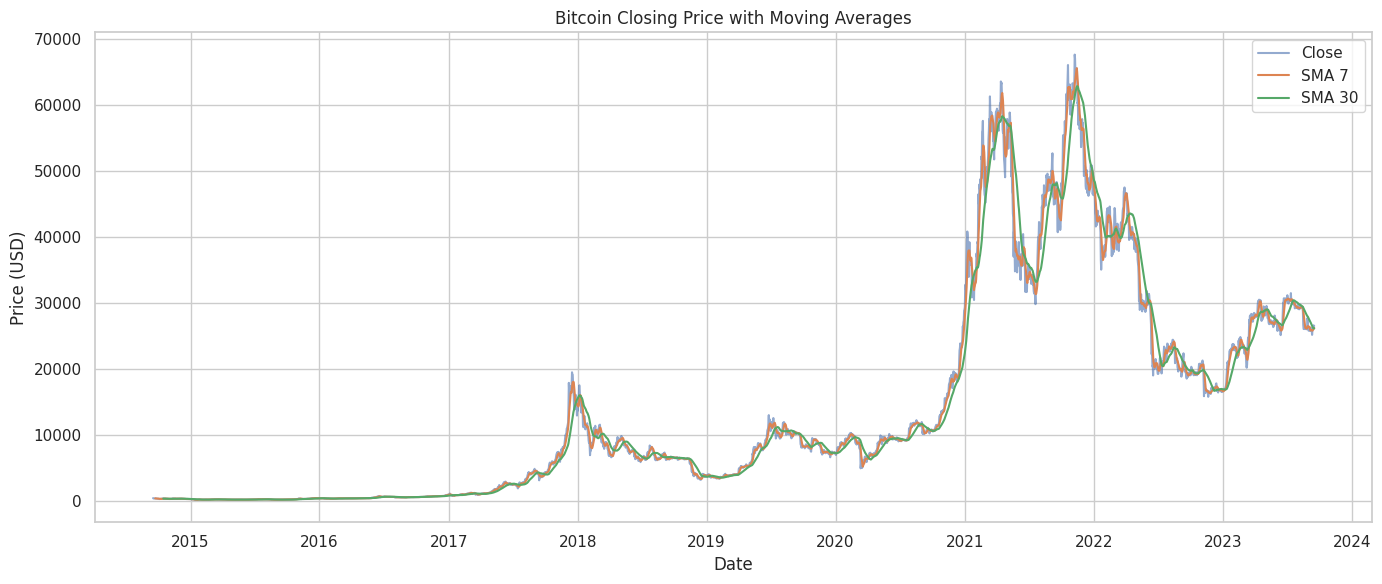

In [ ]:
plt.figure(figsize=(14, 6))

plt.plot(df["Date"], df["Close"], label="Close", alpha=0.6)
plt.plot(df["Date"], df["SMA_7"], label="SMA 7")
plt.plot(df["Date"], df["SMA_30"], label="SMA 30")

plt.title("Bitcoin Closing Price with Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()

plt.tight_layout()
plt.show()

# Create Exponential Moving Averages (EMA)

In [ ]:
# Exponential Moving Averages

df["EMA_9"] = df["Close"].ewm(span=9, adjust=False).mean()

df["EMA_21"] = df["Close"].ewm(span=21, adjust=False).mean()

df[["Date", "Close", "EMA_9", "EMA_21"]].head()

,Date,Close,EMA_9,EMA_21
0,2014-09-17,457.334015,457.334015,457.334015
1,2014-09-18,424.440002,450.755212,454.343650
2,2014-09-19,394.795990,439.563368,448.930227
3,2014-09-20,408.903992,433.431493,445.291478
4,2014-09-21,398.821014,426.509397,441.066890


## Relative Strength Index (RSI)

The Relative Strength Index (RSI) is a momentum indicator that measures the magnitude of recent price movements.

Traditionally:

- RSI above 70 may indicate an overbought market.
- RSI below 30 may indicate an oversold market.

In [ ]:
# Calculate RSI

delta = df["Close"].diff()

gain = delta.where(delta > 0, 0)

loss = -delta.where(delta < 0, 0)

avg_gain = gain.rolling(window=14).mean()

avg_loss = loss.rolling(window=14).mean()

rs = avg_gain / avg_loss

df["RSI"] = 100 - (100 / (1 + rs))

df[["Date", "Close", "RSI"]].head(20)

,Date,Close,RSI
0,2014-09-17,457.334015,NaN
1,2014-09-18,424.440002,NaN
2,2014-09-19,394.795990,NaN
3,2014-09-20,408.903992,NaN
4,2014-09-21,398.821014,NaN
5,2014-09-22,402.152008,NaN
6,2014-09-23,435.790985,NaN
7,2014-09-24,423.204987,NaN
8,2014-09-25,411.574005,NaN
9,2014-09-26,404.424988,NaN


# Visualize RSI

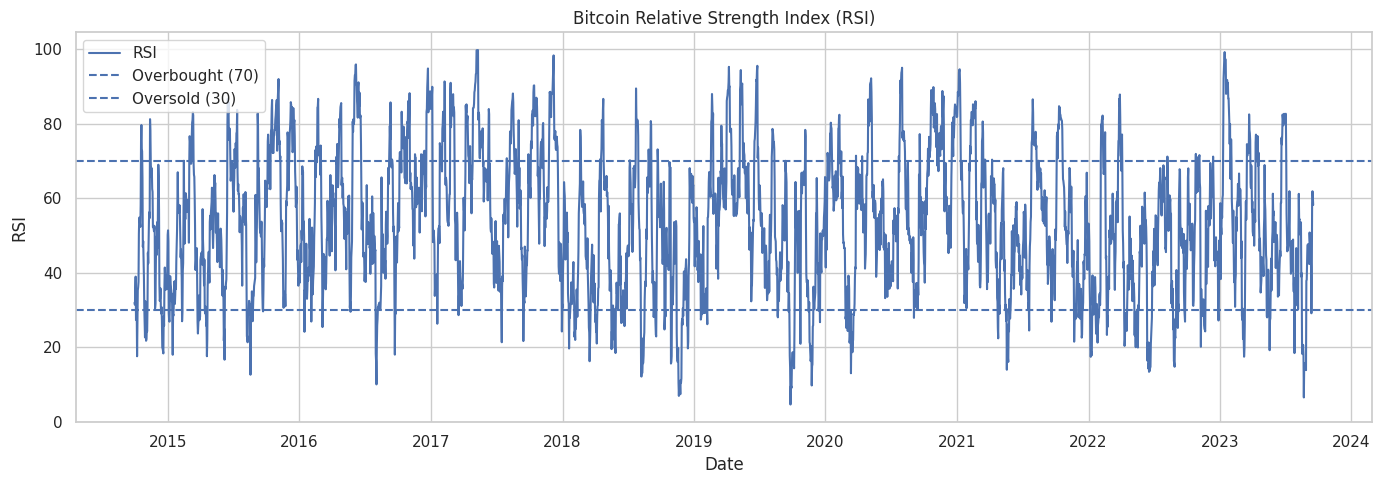

In [ ]:
plt.figure(figsize=(14, 5))

plt.plot(df["Date"], df["RSI"], label="RSI")

plt.axhline(70, linestyle="--", label="Overbought (70)")
plt.axhline(30, linestyle="--", label="Oversold (30)")

plt.title("Bitcoin Relative Strength Index (RSI)")
plt.xlabel("Date")
plt.ylabel("RSI")
plt.legend()

plt.tight_layout()
plt.show()

## Moving Average Convergence Divergence (MACD)

MACD is a momentum indicator calculated using the difference between two exponential moving averages.

For this project:

- Fast EMA = 12 periods
- Slow EMA = 26 periods
- Signal Line = 9 periods

In [ ]:
# Calculate MACD

ema_12 = df["Close"].ewm(span=12, adjust=False).mean()

ema_26 = df["Close"].ewm(span=26, adjust=False).mean()

df["MACD"] = ema_12 - ema_26

df["MACD_Signal"] = df["MACD"].ewm(span=9, adjust=False).mean()

df[["Date", "Close", "MACD", "MACD_Signal"]].head()

,Date,Close,MACD,MACD_Signal
0,2014-09-17,457.334015,0.000000,0.000000
1,2014-09-18,424.440002,-2.624024,-0.524805
2,2014-09-19,394.795990,-7.014744,-1.822793
3,2014-09-20,408.903992,-9.249402,-3.308115
4,2014-09-21,398.821014,-11.699137,-4.986319


# Visualize MACD

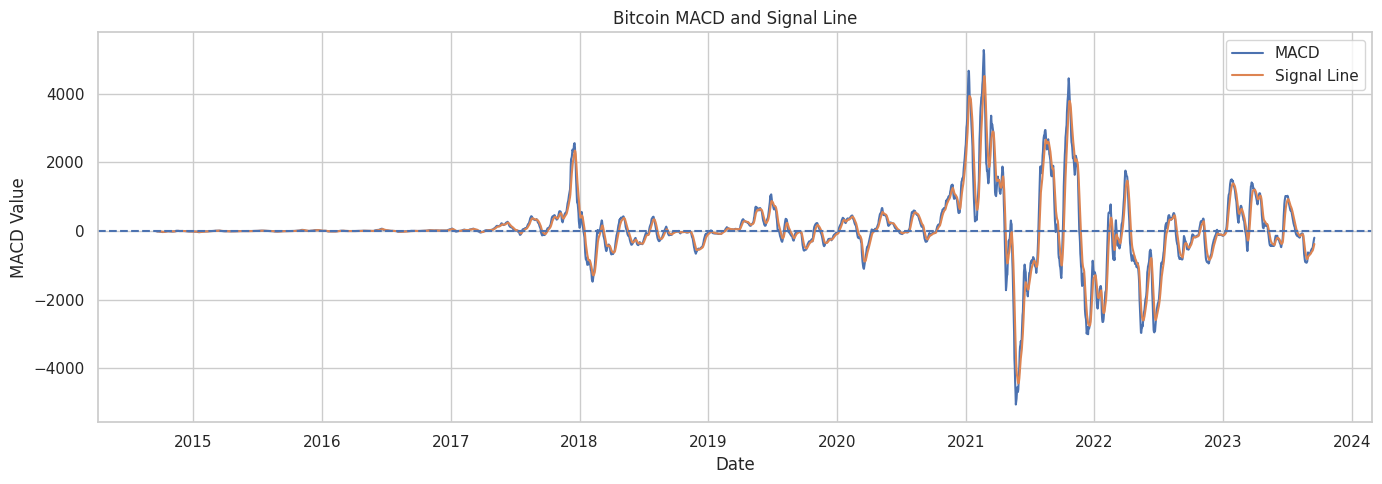

In [ ]:
plt.figure(figsize=(14, 5))

plt.plot(df["Date"], df["MACD"], label="MACD")
plt.plot(df["Date"], df["MACD_Signal"], label="Signal Line")

plt.axhline(0, linestyle="--")

plt.title("Bitcoin MACD and Signal Line")
plt.xlabel("Date")
plt.ylabel("MACD Value")
plt.legend()

plt.tight_layout()
plt.show()

# Create Volatility Feature

In [ ]:
# Calculate 14-day rolling volatility

df["Volatility"] = (
    df["Daily_Return"]
    .rolling(window=14)
    .std()
)

df[["Date", "Daily_Return", "Volatility"]].head(20)

,Date,Daily_Return,Volatility
0,2014-09-17,NaN,NaN
1,2014-09-18,-7.192558,NaN
2,2014-09-19,-6.984264,NaN
3,2014-09-20,3.573492,NaN
4,2014-09-21,-2.465855,NaN
5,2014-09-22,0.835210,NaN
6,2014-09-23,8.364742,NaN
7,2014-09-24,-2.888081,NaN
8,2014-09-25,-2.748309,NaN
9,2014-09-26,-1.736994,NaN


# Create Volume Change

In [ ]:
# Calculate percentage change in trading volume

df["Volume_Change"] = df["Volume"].pct_change() * 100

df[["Date", "Volume", "Volume_Change"]].head()

,Date,Volume,Volume_Change
0,2014-09-17,21056800,NaN
1,2014-09-18,34483200,63.762775
2,2014-09-19,37919700,9.965722
3,2014-09-20,36863600,-2.785096
4,2014-09-21,26580100,-27.896082


# Create Daily Price Range

In [ ]:
# Calculate normalized daily price range

df["Price_Range"] = (
    (df["High"] - df["Low"]) / df["Close"]
) * 100

df[["Date", "High", "Low", "Close", "Price_Range"]].head()

,Date,High,Low,Close,Price_Range
0,2014-09-17,468.174011,452.421997,457.334015,3.444313
1,2014-09-18,456.859985,413.104004,424.440002,10.309109
2,2014-09-19,427.834991,384.532013,394.795990,10.968444
3,2014-09-20,423.295990,389.882996,408.903992,8.171354
4,2014-09-21,412.425995,393.181000,398.821014,4.825472


# Create Trend Features

In [ ]:
# Moving average difference features

df["SMA_Difference"] = (
    (df["SMA_7"] - df["SMA_30"]) / df["SMA_30"]
) * 100

df["EMA_Difference"] = (
    (df["EMA_9"] - df["EMA_21"]) / df["EMA_21"]
) * 100

df[[
    "Date",
    "SMA_7",
    "SMA_30",
    "SMA_Difference",
    "EMA_9",
    "EMA_21",
    "EMA_Difference"
]].head(35)

,Date,SMA_7,SMA_30,SMA_Difference,EMA_9,EMA_21,EMA_Difference
0,2014-09-17,NaN,NaN,NaN,457.334015,457.334015,0.000000
1,2014-09-18,NaN,NaN,NaN,450.755212,454.343650,-0.789807
2,2014-09-19,NaN,NaN,NaN,439.563368,448.930227,-2.086484
3,2014-09-20,NaN,NaN,NaN,433.431493,445.291478,-2.663421
4,2014-09-21,NaN,NaN,NaN,426.509397,441.066890,-3.300518
5,2014-09-22,NaN,NaN,NaN,421.637919,437.529174,-3.632045
6,2014-09-23,417.462572,NaN,NaN,424.468532,437.371157,-2.950040
7,2014-09-24,412.586997,NaN,NaN,424.215823,436.083323,-2.721384
8,2014-09-25,410.748997,NaN,NaN,421.687460,433.855203,-2.804563
9,2014-09-26,412.124568,NaN,NaN,418.234965,431.179729,-3.002174


## Handling Missing Values Created During Feature Engineering

Rolling calculations such as moving averages, RSI, and volatility require historical observations. Therefore, missing values are expected at the beginning of the dataset.

These rows will now be removed before creating the machine learning dataset.

In [ ]:
# Check missing values after feature engineering

print("Missing Values Before Cleaning:")
print(df.isnull().sum())

Missing Values Before Cleaning:
Date               0
Open               0
High               0
Low                0
Close              0
Adj Close          0
Volume             0
Daily_Return       1
SMA_7              6
SMA_14            13
SMA_30            29
EMA_9              0
EMA_21             0
RSI               13
MACD               0
MACD_Signal        0
Volatility        14
Volume_Change      1
Price_Range        0
SMA_Difference    29
EMA_Difference     0
dtype: int64


In [ ]:
# Remove rows containing missing values

df = df.dropna().reset_index(drop=True)

print("Dataset Shape After Removing Missing Values:", df.shape)

print("\nRemaining Missing Values:")
print(df.isnull().sum().sum())

Dataset Shape After Removing Missing Values: (3259, 21)

Remaining Missing Values:
0


# Final Engineered Dataset

In [ ]:
print("Final Dataset Columns:")

for column in df.columns:
    print("-", column)

print("\nDataset Shape:", df.shape)

df.head()

Final Dataset Columns:
- Date
- Open
- High
- Low
- Close
- Adj Close
- Volume
- Daily_Return
- SMA_7
- SMA_14
- SMA_30
- EMA_9
- EMA_21
- RSI
- MACD
- MACD_Signal
- Volatility
- Volume_Change
- Price_Range
- SMA_Difference
- EMA_Difference

Dataset Shape: (3259, 21)


,Date,Open,High,Low,Close,Adj Close,Volume,Daily_Return,SMA_7,SMA_14,...,EMA_9,EMA_21,RSI,MACD,MACD_Signal,Volatility,Volume_Change,Price_Range,SMA_Difference,EMA_Difference
0,2014-10-16,394.518005,398.807007,373.070007,382.556000,382.556000,26990000,-3.094692,381.574720,361.724505,...,379.120471,380.364027,52.336359,-7.086205,-14.590592,3.868463,6.818748,6.727642,-0.660765,-0.326938
1,2014-10-17,382.756012,385.477997,375.389008,383.757996,383.757996,13600700,0.314201,384.745575,363.456362,...,380.047976,380.672569,58.314477,-6.039892,-12.880452,3.659754,-49.608373,2.628998,0.808391,-0.164076
2,2014-10-18,383.976013,395.157990,378.971008,391.441986,391.441986,11416800,2.002301,388.908857,367.926075,...,382.326778,381.651607,75.469711,-4.538333,-11.212028,2.577665,-16.057262,4.135219,2.193745,0.176908
3,2014-10-19,391.253998,393.938995,386.457001,389.545990,389.545990,5914570,-0.484362,390.479854,372.857217,...,383.770620,382.369278,79.658723,-3.461426,-9.661908,2.395155,-48.194152,1.920696,2.653762,0.366489
4,2014-10-20,389.230988,390.084015,378.252014,382.845001,382.845001,16419000,-1.720205,389.398568,376.626216,...,383.585497,382.412526,73.241668,-3.112802,-8.352087,2.488364,177.602598,3.090546,2.603803,0.306729


# 6. Target Variable Creation

The objective of this project is to predict the direction of Bitcoin's closing price for the following day.

The target variable is defined as:

- **1 (UP):** Tomorrow's closing price is higher than today's closing price.
- **0 (DOWN):** Tomorrow's closing price is lower than or equal to today's closing price.

This transforms the problem into a binary classification task.

# Tomorrow's Closing Price

In [ ]:
# Create tomorrow's closing price

df["Tomorrow_Close"] = df["Close"].shift(-1)

df[["Date", "Close", "Tomorrow_Close"]].head()

,Date,Close,Tomorrow_Close
0,2014-10-16,382.556000,383.757996
1,2014-10-17,383.757996,391.441986
2,2014-10-18,391.441986,389.545990
3,2014-10-19,389.545990,382.845001
4,2014-10-20,382.845001,386.475006


# Target Variable

In [ ]:
# Create target variable
# 1 = Price goes UP tomorrow
# 0 = Price goes DOWN or remains the same

df["Target"] = (
    df["Tomorrow_Close"] > df["Close"]
).astype(int)

df[["Date", "Close", "Tomorrow_Close", "Target"]].head(10)

,Date,Close,Tomorrow_Close,Target
0,2014-10-16,382.556000,383.757996,1
1,2014-10-17,383.757996,391.441986,1
2,2014-10-18,391.441986,389.545990,0
3,2014-10-19,389.545990,382.845001,0
4,2014-10-20,382.845001,386.475006,1
5,2014-10-21,386.475006,383.157990,0
6,2014-10-22,383.157990,358.416992,0
7,2014-10-23,358.416992,358.345001,0
8,2014-10-24,358.345001,347.270996,0
9,2014-10-25,347.270996,354.704010,1


# Remove the Final Row

In [ ]:
# Remove the last row because tomorrow's closing price is unavailable

df = df.dropna(subset=["Tomorrow_Close"]).reset_index(drop=True)

print("Dataset Shape:", df.shape)
print("Missing Tomorrow_Close values:", df["Tomorrow_Close"].isnull().sum())

Dataset Shape: (3258, 23)
Missing Tomorrow_Close values: 0


## Target Class Distribution

Before training machine learning models, the distribution of the target variable is examined to identify whether the dataset contains class imbalance.

In [ ]:
# Count target classes

target_counts = df["Target"].value_counts().sort_index()

print("Target Distribution:")
print(target_counts)

print("\nTarget Percentage:")
print((df["Target"].value_counts(normalize=True).sort_index() * 100).round(2))

Target Distribution:
Target
0    1532
1    1726
Name: count, dtype: int64

Target Percentage:
Target
0    47.02
1    52.98
Name: proportion, dtype: float64


# Visualize Target Distribution

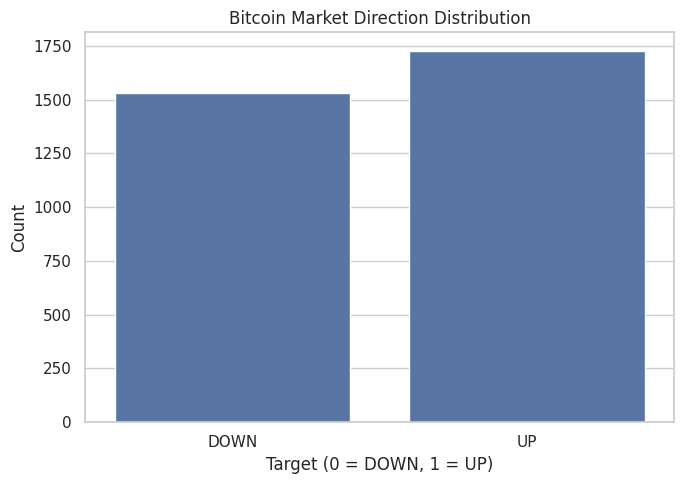

In [ ]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Target")

plt.title("Bitcoin Market Direction Distribution")
plt.xlabel("Target (0 = DOWN, 1 = UP)")
plt.ylabel("Count")

plt.xticks([0, 1], ["DOWN", "UP"])

plt.tight_layout()
plt.show()

In [ ]:
# Remove future information column to prevent data leakage

df = df.drop(columns=["Tomorrow_Close"])

print("Tomorrow_Close removed successfully.")

Tomorrow_Close removed successfully.


# Features for the ML Model

In [ ]:
# Select features for machine learning

feature_columns = [
    "Daily_Return",
    "SMA_7",
    "SMA_14",
    "SMA_30",
    "EMA_9",
    "EMA_21",
    "RSI",
    "MACD",
    "MACD_Signal",
    "Volatility",
    "Volume_Change",
    "Price_Range",
    "SMA_Difference",
    "EMA_Difference"
]

X = df[feature_columns]

y = df["Target"]

print("Feature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)

print("\nFeatures Used:")
print(feature_columns)

Feature Matrix Shape: (3258, 14)
Target Shape: (3258,)

Features Used:
['Daily_Return', 'SMA_7', 'SMA_14', 'SMA_30', 'EMA_9', 'EMA_21', 'RSI', 'MACD', 'MACD_Signal', 'Volatility', 'Volume_Change', 'Price_Range', 'SMA_Difference', 'EMA_Difference']


# Dataset Inspection

In [ ]:
print("Final ML Dataset Preview:")
display(df[feature_columns + ["Target"]].head())

print("\nFinal Dataset Shape:", df.shape)

Final ML Dataset Preview:


,Daily_Return,SMA_7,SMA_14,SMA_30,EMA_9,EMA_21,RSI,MACD,MACD_Signal,Volatility,Volume_Change,Price_Range,SMA_Difference,EMA_Difference,Target
0,-3.094692,381.574720,361.724505,384.112801,379.120471,380.364027,52.336359,-7.086205,-14.590592,3.868463,6.818748,6.727642,-0.660765,-0.326938,1
1,0.314201,384.745575,363.456362,381.660267,380.047976,380.672569,58.314477,-6.039892,-12.880452,3.659754,-49.608373,2.628998,0.808391,-0.164076,1
2,2.002301,388.908857,367.926075,380.560333,382.326778,381.651607,75.469711,-4.538333,-11.212028,2.577665,-16.057262,4.135219,2.193745,0.176908,0
3,-0.484362,390.479854,372.857217,380.385333,383.770620,382.369278,79.658723,-3.461426,-9.661908,2.395155,-48.194152,1.920696,2.653762,0.366489,0
4,-1.720205,389.398568,376.626216,379.516700,383.585497,382.412526,73.241668,-3.112802,-8.352087,2.488364,177.602598,3.090546,2.603803,0.306729,1



Final Dataset Shape: (3258, 22)


# Chronological Train-Test Split

# 7. Train-Test Split

Since Bitcoin market data is time-series data, the dataset is split chronologically instead of randomly.

The older observations are used for training, while the most recent observations are reserved for testing.

This approach better simulates a real-world prediction scenario and helps prevent information leakage from future data.

In [ ]:
# Chronological 80-20 train-test split

split_index = int(len(X) * 0.80)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training Set Shape:", X_train.shape)
print("Testing Set Shape:", X_test.shape)

print("\nTraining Date Range:")
print(df["Date"].iloc[0], "to", df["Date"].iloc[split_index - 1])

print("\nTesting Date Range:")
print(df["Date"].iloc[split_index], "to", df["Date"].iloc[-1])

Training Set Shape: (2606, 14)
Testing Set Shape: (652, 14)

Training Date Range:
2014-10-16 00:00:00 to 2021-12-03 00:00:00

Testing Date Range:
2021-12-04 00:00:00 to 2023-09-16 00:00:00


# Check Train/Test Target Distribution

In [ ]:
print("Training Target Distribution:")
print(y_train.value_counts(normalize=True).sort_index().round(3))

print("\nTesting Target Distribution:")
print(y_test.value_counts(normalize=True).sort_index().round(3))

Training Target Distribution:
Target
0    0.455
1    0.545
Name: proportion, dtype: float64

Testing Target Distribution:
Target
0    0.529
1    0.471
Name: proportion, dtype: float64


## Machine Learning Data Preparation Summary

The dataset was prepared for machine learning using the following process:

1. Technical indicators and market-based features were engineered.
2. Tomorrow's closing price was temporarily created to define the prediction target.
3. The target variable was encoded as:
   - 1 = Bitcoin price moves UP the next day
   - 0 = Bitcoin price moves DOWN or remains unchanged
4. The future price column was removed to prevent data leakage.
5. Relevant technical indicators were selected as model features.
6. The dataset was split chronologically using an 80-20 train-test split.

The chronological split ensures that the model is trained on historical data and evaluated on unseen future data, simulating a more realistic market prediction scenario.

# 8. Machine Learning Model Training

Multiple machine learning classification models are trained to predict the next day's Bitcoin market direction.

The following models are evaluated:

1. Logistic Regression
2. Random Forest Classifier
3. XGBoost Classifier

Model performance is compared using Accuracy, Precision, Recall, F1 Score, and ROC-AUC.

In [ ]:
# Logistic Regression Pipeline

logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

# Train the model
logistic_model.fit(X_train, y_train)

# Predictions
y_pred_lr = logistic_model.predict(X_test)

# Prediction probabilities
y_prob_lr = logistic_model.predict_proba(X_test)[:, 1]

print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


# Evaluate Logistic Regression

In [ ]:
# Logistic Regression Evaluation

lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr, zero_division=0)
lr_recall = recall_score(y_test, y_pred_lr, zero_division=0)
lr_f1 = f1_score(y_test, y_pred_lr, zero_division=0)
lr_auc = roc_auc_score(y_test, y_prob_lr)

print("Logistic Regression Results")
print("-" * 35)

print(f"Accuracy:  {lr_accuracy:.4f}")
print(f"Precision: {lr_precision:.4f}")
print(f"Recall:    {lr_recall:.4f}")
print(f"F1 Score:  {lr_f1:.4f}")
print(f"ROC-AUC:   {lr_auc:.4f}")

Logistic Regression Results
-----------------------------------
Accuracy:  0.4632
Precision: 0.4562
Recall:    0.7296
F1 Score:  0.5614
ROC-AUC:   0.4893


# Logistic Regression Classification Report

In [ ]:
print("Classification Report:\n")

print(
    classification_report(
        y_test,
        y_pred_lr,
        target_names=["DOWN", "UP"],
        zero_division=0
    )
)

Classification Report:

              precision    recall  f1-score   support

        DOWN       0.48      0.23      0.31       345
          UP       0.46      0.73      0.56       307

    accuracy                           0.46       652
   macro avg       0.47      0.48      0.43       652
weighted avg       0.47      0.46      0.43       652



# Logistic Regression Confusion Matrix

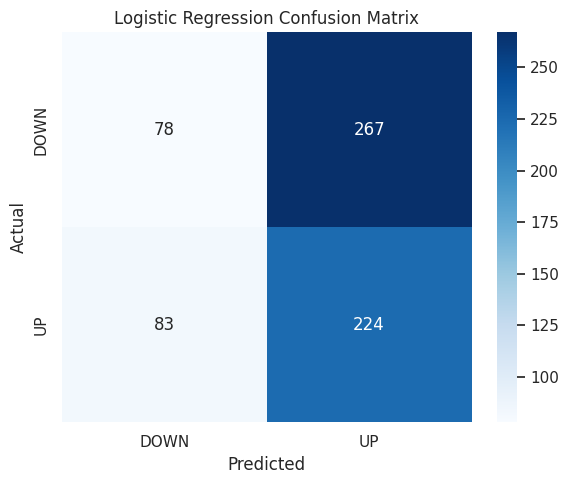

In [ ]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    confusion_matrix(y_test, y_pred_lr),
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["DOWN", "UP"],
    yticklabels=["DOWN", "UP"]
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

## Random Forest Classifier

Random Forest is an ensemble learning algorithm that combines multiple decision trees to capture non-linear relationships between the engineered technical indicators and Bitcoin market direction.

In [ ]:
# Random Forest Model

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

# Train model
rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)

# Prediction probabilities
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest trained successfully!")

Random Forest trained successfully!


# Evaluate Random Forest

In [ ]:
# Random Forest Evaluation

rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf, zero_division=0)
rf_recall = recall_score(y_test, y_pred_rf, zero_division=0)
rf_f1 = f1_score(y_test, y_pred_rf, zero_division=0)
rf_auc = roc_auc_score(y_test, y_prob_rf)

print("Random Forest Results")
print("-" * 35)

print(f"Accuracy:  {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall:    {rf_recall:.4f}")
print(f"F1 Score:  {rf_f1:.4f}")
print(f"ROC-AUC:   {rf_auc:.4f}")

Random Forest Results
-----------------------------------
Accuracy:  0.4985
Precision: 0.4814
Recall:    0.8436
F1 Score:  0.6130
ROC-AUC:   0.5036


# Random Forest Classification Report

In [ ]:
print("Classification Report:\n")

print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=["DOWN", "UP"],
        zero_division=0
    )
)

Classification Report:

              precision    recall  f1-score   support

        DOWN       0.58      0.19      0.29       345
          UP       0.48      0.84      0.61       307

    accuracy                           0.50       652
   macro avg       0.53      0.52      0.45       652
weighted avg       0.53      0.50      0.44       652



# Random Forest Confusion Matrix

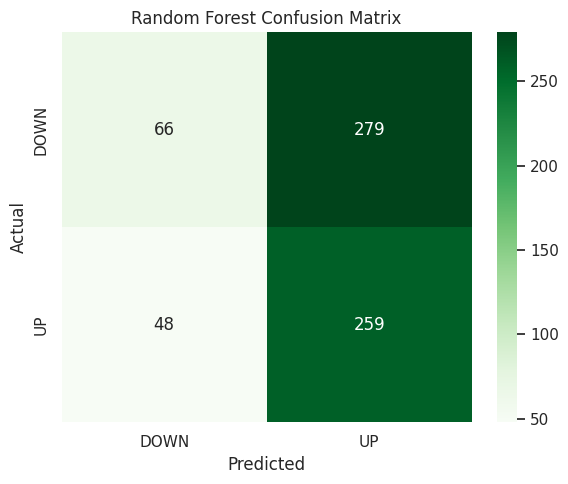

In [ ]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    confusion_matrix(y_test, y_pred_rf),
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["DOWN", "UP"],
    yticklabels=["DOWN", "UP"]
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

## XGBoost Classifier

XGBoost is a gradient boosting algorithm designed to build strong predictive models by combining multiple sequential decision trees.

In [ ]:
# XGBoost Model

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

# Train model
xgb_model.fit(X_train, y_train)

# Predictions
y_pred_xgb = xgb_model.predict(X_test)

# Prediction probabilities
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("XGBoost trained successfully!")

XGBoost trained successfully!


# Evaluate XGBoost

In [ ]:
# XGBoost Evaluation

xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
xgb_precision = precision_score(y_test, y_pred_xgb, zero_division=0)
xgb_recall = recall_score(y_test, y_pred_xgb, zero_division=0)
xgb_f1 = f1_score(y_test, y_pred_xgb, zero_division=0)
xgb_auc = roc_auc_score(y_test, y_prob_xgb)

print("XGBoost Results")
print("-" * 35)

print(f"Accuracy:  {xgb_accuracy:.4f}")
print(f"Precision: {xgb_precision:.4f}")
print(f"Recall:    {xgb_recall:.4f}")
print(f"F1 Score:  {xgb_f1:.4f}")
print(f"ROC-AUC:   {xgb_auc:.4f}")

XGBoost Results
-----------------------------------
Accuracy:  0.5046
Precision: 0.4848
Recall:    0.8339
F1 Score:  0.6132
ROC-AUC:   0.5233


# XGBoost Classification Report

In [ ]:
print("Classification Report:\n")

print(
    classification_report(
        y_test,
        y_pred_xgb,
        target_names=["DOWN", "UP"],
        zero_division=0
    )
)

Classification Report:

              precision    recall  f1-score   support

        DOWN       0.59      0.21      0.31       345
          UP       0.48      0.83      0.61       307

    accuracy                           0.50       652
   macro avg       0.54      0.52      0.46       652
weighted avg       0.54      0.50      0.45       652



# XGBoost Confusion Matrix

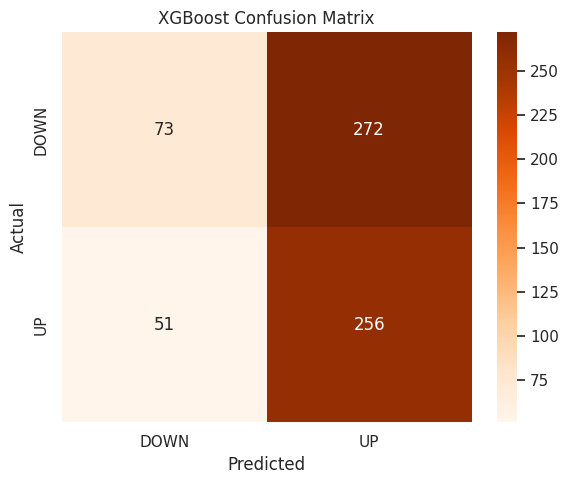

In [ ]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    confusion_matrix(y_test, y_pred_xgb),
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=["DOWN", "UP"],
    yticklabels=["DOWN", "UP"]
)

plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

# Professional Model Comparison Table

In [ ]:
# Create model comparison dataframe

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        lr_accuracy,
        rf_accuracy,
        xgb_accuracy
    ],
    "Precision": [
        lr_precision,
        rf_precision,
        xgb_precision
    ],
    "Recall": [
        lr_recall,
        rf_recall,
        xgb_recall
    ],
    "F1 Score": [
        lr_f1,
        rf_f1,
        xgb_f1
    ],
    "ROC-AUC": [
        lr_auc,
        rf_auc,
        xgb_auc
    ]
})

results = results.sort_values(
    by="F1 Score",
    ascending=False
).reset_index(drop=True)

results.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,XGBoost,0.5046,0.4848,0.8339,0.6132,0.5233
1,Random Forest,0.4985,0.4814,0.8436,0.6130,0.5036
2,Logistic Regression,0.4632,0.4562,0.7296,0.5614,0.4893


# Visualize Model Comparison

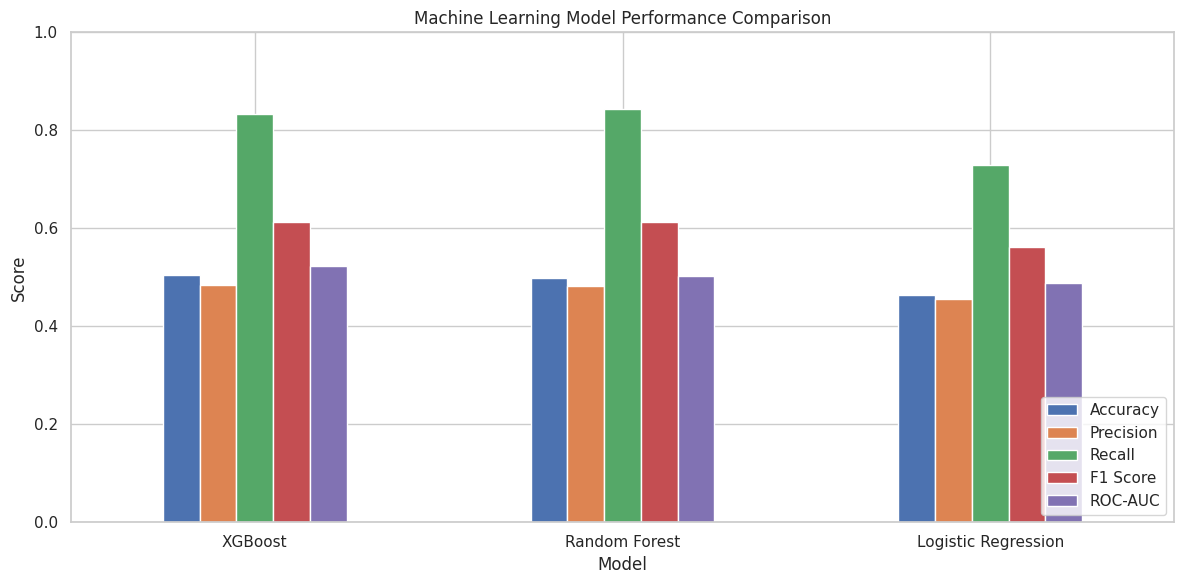

In [ ]:
# Model comparison visualization

results_plot = results.set_index("Model")

results_plot[
    ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]
].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Machine Learning Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)

plt.legend(loc="lower right")

plt.tight_layout()
plt.show()

# Best Initial Model

In [ ]:
best_initial_model_name = results.iloc[0]["Model"]

print("Best Initial Model:", best_initial_model_name)
print("Best F1 Score:", round(results.iloc[0]["F1 Score"], 4))

Best Initial Model: XGBoost
Best F1 Score: 0.6132


## Initial Model Comparison Summary

Three classification models were trained and evaluated using a chronological test dataset.

- Logistic Regression was used as the baseline model.
- Random Forest was used to capture non-linear relationships between technical indicators.
- XGBoost was used as an advanced gradient boosting approach.

The models were evaluated using Accuracy, Precision, Recall, F1 Score, and ROC-AUC.

The best initial model was selected based primarily on the F1 Score, while also considering the overall balance between precision, recall, and ROC-AUC.

# 9. Hyperparameter Tuning

Based on the initial model comparison, XGBoost achieved the highest F1 Score and ROC-AUC among the evaluated models.

Therefore, XGBoost is selected for hyperparameter tuning.

Since this project uses chronological financial time-series data, `TimeSeriesSplit` will be used for cross-validation instead of random cross-validation. This helps preserve the temporal order of observations and reduces the risk of information leakage.

# Import TimeSeriesSplit and RandomizedSearchCV

In [ ]:
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV

# Time Series Cross-Validation

In [ ]:
# Create TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

print("TimeSeriesSplit created successfully!")

TimeSeriesSplit created successfully!


# XGBoost Parameter Grid

In [ ]:
# Define hyperparameter search space

param_distributions = {
    "n_estimators": [100, 200, 300, 400],
    "max_depth": [3, 4, 5, 6],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5]
}

# Base XGBoost Model

In [ ]:
# Base XGBoost model for tuning

xgb_base = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

# RandomizedSearchCV

In [ ]:
random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_distributions,
    n_iter=25,
    scoring="roc_auc",
    cv=tscv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# Hyperparameter Tuning

In [ ]:
# Train RandomizedSearchCV

random_search.fit(X_train, y_train)

print("Hyperparameter tuning completed!")

Fitting 5 folds for each of 25 candidates, totalling 125 fits
Hyperparameter tuning completed!


# Best Parameters

In [ ]:
print("Best Parameters:")
print(random_search.best_params_)

print("\nBest Cross-Validation ROC-AUC:")
print(round(random_search.best_score_, 4))

Best Parameters:
{'subsample': 0.8, 'n_estimators': 200, 'min_child_weight': 3, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 0.7}

Best Cross-Validation ROC-AUC:
0.5292


# Best Tuned Model

In [ ]:
best_xgb_model = random_search.best_estimator_

print("Best XGBoost model selected successfully!")

Best XGBoost model selected successfully!


# Tuned XGBoost Model

In [ ]:
# Predictions

y_pred_tuned = best_xgb_model.predict(X_test)

y_prob_tuned = best_xgb_model.predict_proba(X_test)[:, 1]

# Metrics

tuned_accuracy = accuracy_score(y_test, y_pred_tuned)
tuned_precision = precision_score(
    y_test,
    y_pred_tuned,
    zero_division=0
)
tuned_recall = recall_score(
    y_test,
    y_pred_tuned,
    zero_division=0
)
tuned_f1 = f1_score(
    y_test,
    y_pred_tuned,
    zero_division=0
)
tuned_auc = roc_auc_score(y_test, y_prob_tuned)

print("Tuned XGBoost Results")
print("-" * 35)

print(f"Accuracy:  {tuned_accuracy:.4f}")
print(f"Precision: {tuned_precision:.4f}")
print(f"Recall:    {tuned_recall:.4f}")
print(f"F1 Score:  {tuned_f1:.4f}")
print(f"ROC-AUC:   {tuned_auc:.4f}")

Tuned XGBoost Results
-----------------------------------
Accuracy:  0.4923
Precision: 0.4762
Recall:    0.7818
F1 Score:  0.5919
ROC-AUC:   0.5328


# Tuned Model Classification Report

In [ ]:
print(
    classification_report(
        y_test,
        y_pred_tuned,
        target_names=["DOWN", "UP"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

        DOWN       0.55      0.23      0.33       345
          UP       0.48      0.78      0.59       307

    accuracy                           0.49       652
   macro avg       0.51      0.51      0.46       652
weighted avg       0.51      0.49      0.45       652



# Tuned Model Confusion Matrix

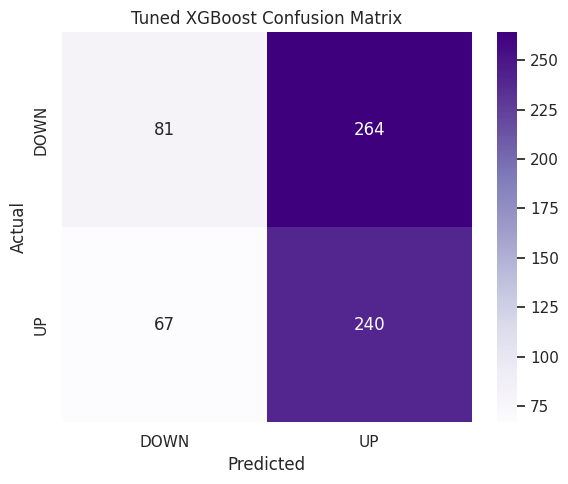

In [ ]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    confusion_matrix(y_test, y_pred_tuned),
    annot=True,
    fmt="d",
    cmap="Purples",
    xticklabels=["DOWN", "UP"],
    yticklabels=["DOWN", "UP"]
)

plt.title("Tuned XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

# Initial vs Tuned XGBoost

In [ ]:
tuning_comparison = pd.DataFrame({
    "Model": [
        "Initial XGBoost",
        "Tuned XGBoost"
    ],
    "Accuracy": [
        xgb_accuracy,
        tuned_accuracy
    ],
    "Precision": [
        xgb_precision,
        tuned_precision
    ],
    "Recall": [
        xgb_recall,
        tuned_recall
    ],
    "F1 Score": [
        xgb_f1,
        tuned_f1
    ],
    "ROC-AUC": [
        xgb_auc,
        tuned_auc
    ]
})

tuning_comparison.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Initial XGBoost,0.5046,0.4848,0.8339,0.6132,0.5233
1,Tuned XGBoost,0.4923,0.4762,0.7818,0.5919,0.5328


# Model Decision

In [ ]:
if tuned_f1 > xgb_f1:
    final_model = best_xgb_model
    final_model_name = "Tuned XGBoost"
    print("Final Model: Tuned XGBoost")
else:
    final_model = xgb_model
    final_model_name = "Initial XGBoost"
    print("Final Model: Initial XGBoost")

print(f"Final Model F1 Score: {max(tuned_f1, xgb_f1):.4f}")

Final Model: Initial XGBoost
Final Model F1 Score: 0.6132


# Feature Importance

In [ ]:
# Get feature importance

feature_importance = pd.DataFrame({
    "Feature": feature_columns,
    "Importance": final_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
5,EMA_21,0.078808
2,SMA_14,0.077974
13,EMA_Difference,0.076761
0,Daily_Return,0.076308
6,RSI,0.074794
7,MACD,0.072326
8,MACD_Signal,0.070925
3,SMA_30,0.070249
10,Volume_Change,0.069211
4,EMA_9,0.069147


# Visualize Feature Importance

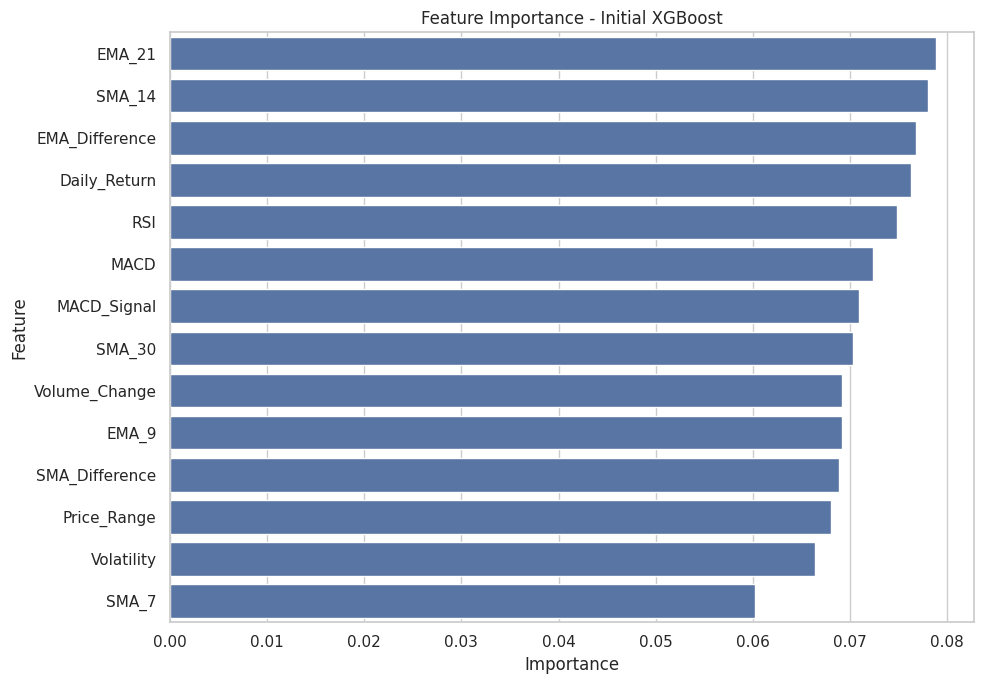

In [ ]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title(f"Feature Importance - {final_model_name}")

plt.tight_layout()
plt.show()

# 10. Final Model Selection

After comparing Logistic Regression, Random Forest, XGBoost, and the tuned XGBoost model, the Initial XGBoost model was selected as the final model.

Although hyperparameter tuning slightly improved ROC-AUC, the initial XGBoost model achieved better overall performance in Accuracy, Precision, Recall, and F1 Score.

The final model selection was based primarily on F1 Score.

**Final Model: XGBoost Classifier**

**Final F1 Score: 0.6132**

The results demonstrate the difficulty of predicting short-term cryptocurrency market movements using only historical price data and technical indicators.

# Model Artifacts Folder

In [ ]:
import os

os.makedirs("model_artifacts", exist_ok=True)

print("Model artifacts folder created successfully!")

Model artifacts folder created successfully!


# Final Model

In [ ]:
# Save the final trained model

model_path = "model_artifacts/bitcoin_xgboost_model.pkl"

joblib.dump(final_model, model_path)

print(f"Model saved successfully at: {model_path}")

Model saved successfully at: model_artifacts/bitcoin_xgboost_model.pkl


# Feature Names

In [ ]:
# Save feature names

feature_path = "model_artifacts/feature_columns.pkl"

joblib.dump(feature_columns, feature_path)

print(f"Feature list saved successfully at: {feature_path}")

Feature list saved successfully at: model_artifacts/feature_columns.pkl


# Create Model Metadata

In [ ]:
model_metadata = {
    "model_name": final_model_name,
    "problem_type": "Binary Classification",
    "target": "Next Day Bitcoin Market Direction",
    "target_classes": {
        0: "DOWN",
        1: "UP"
    },
    "features": feature_columns,
    "dataset_period": "2014-09-17 to 2023-09-17",
    "best_f1_score": float(xgb_f1),
    "best_accuracy": float(xgb_accuracy),
    "best_roc_auc": float(xgb_auc)
}

metadata_path = "model_artifacts/model_metadata.pkl"

joblib.dump(model_metadata, metadata_path)

print("Model metadata saved successfully!")

Model metadata saved successfully!


# Verify Saved Files

In [ ]:
# Check saved files

print("Saved Model Artifacts:")

for file in os.listdir("model_artifacts"):
    file_path = os.path.join("model_artifacts", file)
    file_size = os.path.getsize(file_path)

    print(f"{file} - {file_size / 1024:.2f} KB")

Saved Model Artifacts:
feature_columns.pkl - 0.17 KB
model_metadata.pkl - 0.45 KB
bitcoin_xgboost_model.pkl - 309.29 KB


# Test Loading the Model

In [ ]:
# Load saved model

loaded_model = joblib.load(
    "model_artifacts/bitcoin_xgboost_model.pkl"
)

loaded_features = joblib.load(
    "model_artifacts/feature_columns.pkl"
)

print("Model loaded successfully!")

print("\nNumber of Features:")
print(len(loaded_features))

print("\nFeatures:")
print(loaded_features)

Model loaded successfully!

Number of Features:
14

Features:
['Daily_Return', 'SMA_7', 'SMA_14', 'SMA_30', 'EMA_9', 'EMA_21', 'RSI', 'MACD', 'MACD_Signal', 'Volatility', 'Volume_Change', 'Price_Range', 'SMA_Difference', 'EMA_Difference']


# Test Model Prediction After Loading

In [ ]:
# Test loaded model using first test sample

sample_data = X_test.iloc[[0]]

sample_prediction = loaded_model.predict(sample_data)[0]

sample_probability = loaded_model.predict_proba(sample_data)[0][1]

prediction_label = "UP 📈" if sample_prediction == 1 else "DOWN 📉"

print("Sample Prediction:", prediction_label)
print(f"Probability of UP: {sample_probability:.2%}")

Sample Prediction: UP 📈
Probability of UP: 50.80%


# Deployment Data Sample

In [ ]:
# Save processed dataset for deployment/reference

processed_data_path = "model_artifacts/processed_bitcoin_data.csv"

df.to_csv(processed_data_path, index=False)

print("Processed dataset saved successfully!")

Processed dataset saved successfully!


## Model Deployment Artifacts

The following artifacts were saved for deployment:

- `bitcoin_xgboost_model.pkl` — Final trained XGBoost classification model.
- `feature_columns.pkl` — Ordered list of features required by the model.
- `model_metadata.pkl` — Project and model metadata.
- `processed_bitcoin_data.csv` — Processed historical dataset used for reference.

The saved model was reloaded and tested successfully to ensure that it can be used in the deployment environment.